In [1]:
import os
os.chdir(r"..\models\..")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import pickle

from tokenizer import Tokenizer
from sentiment_classifier import SentimentClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import random_split, DataLoader, Dataset

In [2]:
# Getting Sources / Data
sources = [
    "data/amazon_cells_labelled.txt",
    "data/imdb_labelled.txt",
    "data/yelp_labelled.txt"
]

# Loading Dataset
def load_dataset(sources):
    texts = []
    labels = []

    for source in sources:
        with open(source, "r", encoding="utf8") as f:

            for line in f:
                if "\t" not in line:
                    continue

                text, label = line.strip().split("\t")
                texts.append(text)
                labels.append(int(label))

    return texts, labels

texts, labels = load_dataset(sources)

In [3]:
# Tokenizing the Text
tokenizer = Tokenizer(vocab_size=10_000)

tokenizer.fit(texts)  # learns vocabulary

vocab_size = len(tokenizer.word_to_idx)
print(f"Vocabulary Size: {vocab_size}")

with open("models/classification_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

Vocabulary Size: 5209


In [4]:
class ClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, seq_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.seq_len = seq_len

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
            text = self.texts[idx]
            label = self.labels[idx]

            # Tokenize single example
            tokens = self.tokenizer.transform(text)

            # Pad / truncate
            tokens = self.tokenizer.pad_sequence(tokens, max_len=self.seq_len)

            return torch.tensor(tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)

In [39]:
# Plotting Metrics Function
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(val_accuracies) + 1)

    # Train Loss Plotting
    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()

    # Valisation Loss Plotting
    plt.subplot(2, 2, 2)
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss")
    plt.grid()
    plt.legend()
    
    # Train Accuracy Plotting
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train Accuracy per Epoch")
    plt.grid()
    plt.legend()

    # Validation Accuracy Plotting
    plt.subplot(2, 2, 4)
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy per Epoch")
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [46]:
# Training Classification Model

# Splitting texts for Training
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42)

train_dataset = ClassificationDataset(
    texts=train_texts,
    labels=train_labels,
    tokenizer=tokenizer,
    seq_len=100
)

val_dataset = ClassificationDataset(
    texts=val_texts,
    labels=val_labels,
    tokenizer=tokenizer,
    seq_len=100
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    max_len=100,
    num_classes=2,
    dropout=0.3,
    device=device).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=20, patience=30):

    best_val_acc = 0
    patience_counter = 0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Training
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            outputs = model(x)

            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = train_loss / total
        train_accuracy = correct / len(train_loader.dataset)
        
        # Evaluation
        model.eval()
        val_loss_total = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss_total += loss.item() * x.size(0)

                preds = outputs.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_loss = val_loss_total / total
        val_accuracy = correct / total

        # Storing for plotting
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        train_accuracies.append(train_accuracy)

            
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}: "
            f"Train Loss = {train_loss:.4f}, Train Acc = {100*train_accuracy:.2f}%, "
            f"Val Loss = {val_loss:.4f}, Val Acc = {100*val_accuracy:.2f}%")

        # Early Stopping and Checkpointing
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            patience_counter = 0
            torch.save(model.state_dict(),"models/classification_best_model.pt")

        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping was trigged at {epoch+1}")
                break

    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)


CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1660
Epoch 1: Train Loss = 0.6989, Train Acc = 48.92%, Val Loss = 0.6937, Val Acc = 50.33%
Epoch 10: Train Loss = 0.5876, Train Acc = 69.04%, Val Loss = 0.5682, Val Acc = 68.67%
Epoch 20: Train Loss = 0.4833, Train Acc = 77.71%, Val Loss = 0.5138, Val Acc = 75.33%
Epoch 30: Train Loss = 0.4520, Train Acc = 79.46%, Val Loss = 0.4973, Val Acc = 77.83%
Epoch 40: Train Loss = 0.4203, Train Acc = 80.46%, Val Loss = 0.4950, Val Acc = 77.50%
Epoch 50: Train Loss = 0.3813, Train Acc = 82.92%, Val Loss = 0.4899, Val Acc = 78.17%
Epoch 60: Train Loss = 0.3431, Train Acc = 85.04%, Val Loss = 0.5032, Val Acc = 78.67%
Epoch 70: Train Loss = 0.3125, Train Acc = 86.50%, Val Loss = 0.5098, Val Acc = 79.33%
Epoch 80: Train Loss = 0.2814, Train Acc = 88.54%, Val Loss = 0.5118, Val Acc = 79.67%
Epoch 90: Train Loss = 0.2686, Train Acc = 88.42%, Val Loss = 0.5566, Val Acc = 79.33%
Epoch 100: Train Loss = 0.2728, Train Acc = 88.33%, Val Loss = 0.50

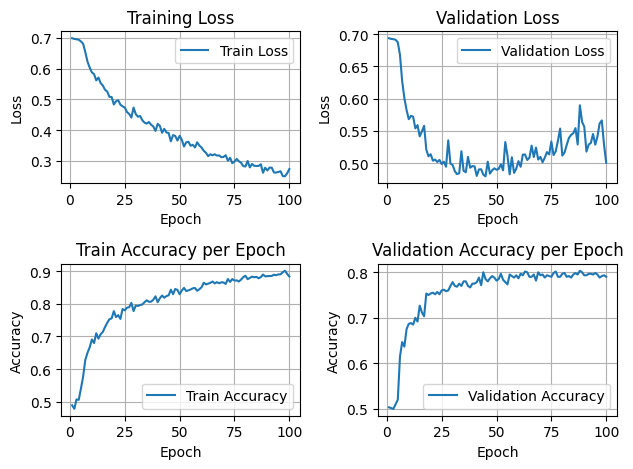

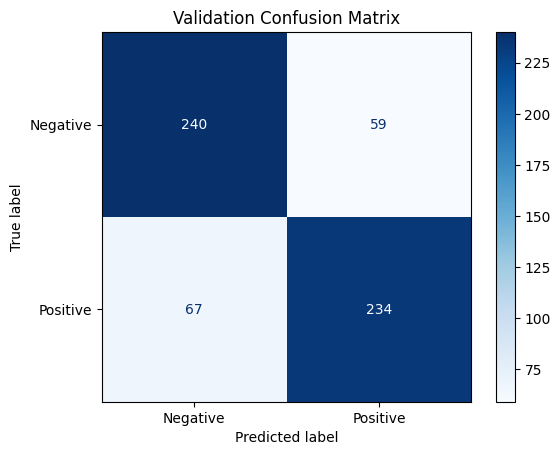

In [47]:
print("\nCUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
train(model, train_loader, val_loader, criterion, optimizer, device, epochs=100)

# Confusion Matrix (True Positives, False Negatives, etc)
y_true = []
y_pred = []

for X_batch, y_batch in val_loader:
    with torch.no_grad():
        outputs = model(X_batch.to(device))
        preds = outputs.argmax(dim=1).cpu()
        y_true.extend(y_batch.cpu())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title('Validation Confusion Matrix')
plt.show()

In [38]:
# Tryin Model
# Tokenizer
with open("models/classification_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Loading the trained model
checkpoint = torch.load("models/classification_best_model.pt")

model = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    max_len=100,
    num_classes=2,
    dropout=0.1,
    device=device).to(device)

# Load the model state
model.load_state_dict(checkpoint)

label_map = {0: "Negative", 1: "Positive"}

def predict_sentiment(sentence, model, tokenizer, max_len, device="cuda"):
    model.eval()

    with torch.no_grad():
        tokens = tokenizer.transform(sentence)
        tokens = tokenizer.pad_sequence(tokens, max_len)
        input_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(input_tensor)

        probs = F.softmax(logits, dim=1)
        prediction = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction].item()
    
        return print(f"{sentence} = {label_map[prediction]}, {100 * confidence:.2f}%")

examples = ["I love you!",
            "I can't believe it",
            "I hate this movie so much!", 
            "I think this was wonderful!",
            "Worst experience of my entire life",
            "I don't love you anymore"]

for example in examples:
    predict_sentiment(example, model, tokenizer, max_len=100)

I love you! = Positive, 100.00%
I can't believe it = Negative, 100.00%
I hate this movie so much! = Negative, 64.32%
I think this was wonderful! = Positive, 99.96%
Worst experience of my entire life = Negative, 100.00%
I don't love you anymore = Negative, 100.00%
